In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import pypsa

## Initial information

Country: Spain

Year: 2011

Technologies:
    - Solar
    - Wind
    - CCGT (gas turbine)
    - Coal
    - Hydro (battery)

## Technologies data and costs
The technology cost and performance assumptions are taken from the PyPSA Technology Data database (PyPSA/technology-data, v0.11.0). 

This database compiles assumptions and projections for a wide range of energy system technologies for different years. The data can be imported into Python and loaded into a pandas.DataFrame. 

In [2]:
year = 2030

url = f"https://raw.githubusercontent.com/PyPSA/technology-data/v0.11.0/outputs/costs_{year}.csv"
costs = pd.read_csv(url, index_col=[0, 1])

In [3]:
costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")

defaults = {
    "FOM": 0,
    "VOM": 0,
    "efficiency": 1,
    "fuel": 0,
    "investment": 0,
    "lifetime": 25,
    "discount rate": 0.07,
}
costs = costs.value.unstack().fillna(defaults)

costs.at["CCGT", "fuel"] = costs.at["gas", "fuel"] # Assign the natural gas fuel cost to the CCGT technology (fuel prices are stored under "gas" in the database)

In [4]:
#calculate annuity
def annuity(r, n):
    return r / (1.0 - 1.0 / (1.0 + r) ** n)

In [5]:
#calculate marginal cost
costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"]

In [6]:
annuity = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1)

In [7]:
#calculate capital cost
costs["capital_cost"] = (annuity + costs["FOM"] / 100) * costs["investment"]

In [8]:
technologies = ["onwind", "solar", "CCGT", "coal", "PHS"]

data = {
    "Capital cost (EUR/MW/a)": [costs.at[t, "capital_cost"] for t in technologies],
    "Marginal cost (EUR/MWh)": [costs.at[t, "marginal_cost"] for t in technologies],
}

cost_table = pd.DataFrame(data, index=technologies)

cost_table

,Capital cost (EUR/MW/a),Marginal cost (EUR/MWh)
onwind,101644.123324,1.428600
solar,51346.829820,0.010600
CCGT,104788.020783,46.803121
coal,337208.027448,30.098840
PHS,182698.734592,0.000000


## Data
For this project, time series data are required for the wind and solar capacity factors, as well as for electricity demand. The datasets used include:
-  Time series of wind capacity factors for European countries
- Time series of solar capacity factors for European countries
- Electricity demand time series

In [9]:
data_solar = pd.read_csv('data/pv_optimal.csv',sep=';')
data_solar.index = pd.DatetimeIndex(data_solar['utc_time'])

data_wind = pd.read_csv('data/onshore_wind_1979-2017.csv',sep=';')
data_wind.index = pd.DatetimeIndex(data_wind['utc_time'])

data_el = pd.read_csv('data/electricity_demand.csv',sep=';')
data_el.index = pd.DatetimeIndex(data_el['utc_time'])

In [10]:
data_solar.head()

,utc_time,AUT,BEL,BGR,BIH,CHE,CYP,CZE,DEU,DNK,...,MLT,NLD,NOR,POL,PRT,ROU,SRB,SVK,SVN,SWE
utc_time,,,,,,,,,,,,,,,,,,,,,
1979-01-01 00:00:00+00:00,1979-01-01T00:00:00Z,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1979-01-01 01:00:00+00:00,1979-01-01T01:00:00Z,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1979-01-01 02:00:00+00:00,1979-01-01T02:00:00Z,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1979-01-01 03:00:00+00:00,1979-01-01T03:00:00Z,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1979-01-01 04:00:00+00:00,1979-01-01T04:00:00Z,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
data_el.head()

,utc_time,ESP
utc_time,,
2011-01-01 00:00:00+00:00,2011-01-01T00:00:00Z,25981.0
2011-01-01 01:00:00+00:00,2011-01-01T01:00:00Z,24709.0
2011-01-01 02:00:00+00:00,2011-01-01T02:00:00Z,22895.0
2011-01-01 03:00:00+00:00,2011-01-01T03:00:00Z,21429.0
2011-01-01 04:00:00+00:00,2011-01-01T04:00:00Z,20425.0


In [12]:
# For this project the chosen country was Spain
country = 'ESP'

## Question A
- Dispatch time series for a week in summer and winter

- Annual electricity mix

- Technologies duration curves

## Joint capacity and dispatch optimization

In [13]:
# create an empty PyPSA network where later we will place buses, generators, loads, storage, lines
# we need a list with all hours in a year because electricty system are balanced every hour
n_nostorage = pypsa.Network()

# creates a list of all hours, length = 8760 (number of hours in a year)
hours = pd.date_range('2011-01-01 00:00Z', '2011-12-31 23:00Z', freq='h')

n_nostorage.set_snapshots(hours.values) 

# a bus is a connection point where electricity is balanced (meeting point in the model)
# generators inject electricity into the bus, loads take electricity from the bus (generation=demand)
n_nostorage.add("Bus", #one bus = single-region model
            "Spain electricity") # one node called Spain electricity

n_nostorage.snapshots

DatetimeIndex(['2011-01-01 00:00:00', '2011-01-01 01:00:00',
               '2011-01-01 02:00:00', '2011-01-01 03:00:00',
               '2011-01-01 04:00:00', '2011-01-01 05:00:00',
               '2011-01-01 06:00:00', '2011-01-01 07:00:00',
               '2011-01-01 08:00:00', '2011-01-01 09:00:00',
               ...
               '2011-12-31 14:00:00', '2011-12-31 15:00:00',
               '2011-12-31 16:00:00', '2011-12-31 17:00:00',
               '2011-12-31 18:00:00', '2011-12-31 19:00:00',
               '2011-12-31 20:00:00', '2011-12-31 21:00:00',
               '2011-12-31 22:00:00', '2011-12-31 23:00:00'],
              dtype='datetime64[ns]', name='snapshot', length=8760, freq=None)

In [14]:
# a carrier is a label for the type of technologies, it defines the categories
carriers = [
    "onwind",
    "solar",
    "coal",
    "CCGT",
]

n_nostorage.add(
    "Carrier",
    carriers,
    color=["dodgerblue", "gold", "indianred","yellow-green"], # colors that represent each carrier
)

In [15]:
# add load to the bus
# load mean electricity consumption (demand), in this case is Spain's electricity demand every hour of 2011
n_nostorage.add("Load",
      "demand", #label, we can call what we want
      bus="Spain electricity",
      p_set=data_el[country].values) #p_set, fixed power consumption, the model cannot change this demand

#demand is fixed because demand is inelastic (demand does not respond to price)

<Axes: xlabel='snapshot', ylabel='MW'>

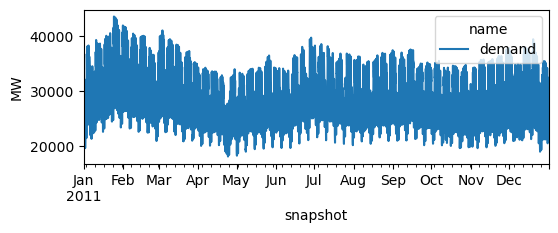

In [16]:
#create a plot with the hourly demand in 2011
n_nostorage.loads_t.p_set.plot(figsize=(6, 2), ylabel="MW")

In [17]:
# adding the generators, which generators exist and characteristics
# CCGT (gas turbine)
n_nostorage.add(
    "Generator",
    "CCGT",
    bus="Spain electricity", #generators put electricity into the bus
    carrier="CCGT",
    # capital cost, marginal cost and efficiency are taken from the prerequisites
    capital_cost=costs.at["CCGT", "capital_cost"],
    marginal_cost=costs.at["CCGT", "marginal_cost"],
    efficiency=costs.at["CCGT", "efficiency"],
    p_nom_extendable=True,
    p_nom_max=25300, # 25.3 GW
)

# coal
n_nostorage.add(
    "Generator",
    "coal",
    bus="Spain electricity", #generators put electricity into the bus
    carrier="coal",
    # capital cost, marginal cost and efficiency are taken from the prerequisites
    capital_cost=costs.at["coal", "capital_cost"],
    marginal_cost=costs.at["coal", "marginal_cost"],
    efficiency=costs.at["coal", "efficiency"],
    p_nom_extendable=True,
    p_nom_max=11700, # 11.7 GW
)

#capacity factor time series that are called in p_max_pu
CF_wind = data_wind[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in n_nostorage.snapshots]]
# Onshore wind
n_nostorage.add(
        "Generator",
        "onwind",
        bus="Spain electricity",
        carrier="onwind",
        p_max_pu=CF_wind.values, # since renewables cannot produce whenever they want, their output is limited by weather data
        capital_cost=costs.at["onwind", "capital_cost"],
        marginal_cost=costs.at["onwind", "marginal_cost"],
        efficiency=costs.at["onwind", "efficiency"],
        p_nom_extendable=True,
    )

#solar capacity factor
CF_solar = data_solar[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in n_nostorage.snapshots]]
# Solar PV
n_nostorage.add(
        "Generator",
        "solar",
        bus="Spain electricity",
        carrier="solar",
        p_max_pu= CF_solar.values,
        capital_cost=costs.at["solar", "capital_cost"],
        marginal_cost=costs.at["solar", "marginal_cost"],
        efficiency=costs.at["solar", "efficiency"],
        p_nom_extendable=True,
    )


# CCGT and coal do not have p_max_pu because is dispatchable, which means it can run whenever needed, as long it does not exceed the installed capacity

<Axes: xlabel='snapshot', ylabel='CF'>

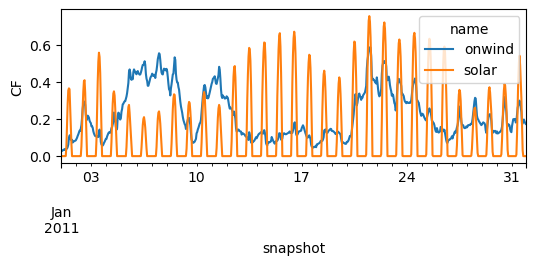

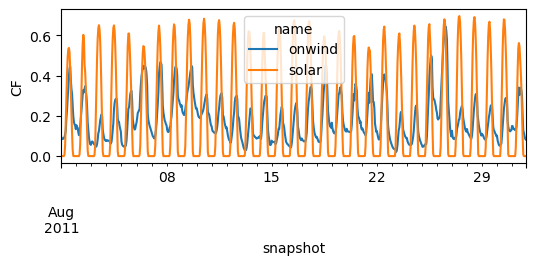

In [18]:
# capacity factors of wind and solar during January 2011 (winter)
n_nostorage.generators_t.p_max_pu.loc["2011-01"].plot(figsize=(6, 2), ylabel="CF") 

# capacity factors of wind and solar during August 2011 (winter)
n_nostorage.generators_t.p_max_pu.loc["2011-08"].plot(figsize=(6, 2), ylabel="CF") 

In [19]:
for df in [n_nostorage.buses, n_nostorage.loads, n_nostorage.generators]:
    for col in df.columns:
        if "ArrowStringArray" in str(type(df[col].array)):
            df[col] = df[col].astype("object")

n_nostorage.buses.index = pd.Index(n_nostorage.buses.index.tolist(), dtype=object)
n_nostorage.loads.index = pd.Index(n_nostorage.loads.index.tolist(), dtype=object)
n_nostorage.generators.index = pd.Index(n_nostorage.generators.index.tolist(), dtype=object)

n_nostorage.buses.index.name = "name"
n_nostorage.loads.index.name = "name"
n_nostorage.generators.index.name = "name"

## Model PyPSA

In [20]:
n_nostorage.optimize(solver_name="highs")
# PyPS decides two things at the same time: capacity (how much technology to build) and dispatch (how much each generator produces in every hour of the year)

C:\Users\User\AppData\Local\Temp\ipykernel_35000\678417549.py:1: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n_nostorage.optimize(solver_name="highs")
Index(['Spain electricity'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 151.93it/s]
INFO:linopy.io: Writing time: 0.16s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 35044 primals, 78846 duals
Objective: 1.85e+10
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


('ok', 'optimal')

In [21]:
# how much capacity the model decided to build (optimised capacities in GW)
opt_caps = n_nostorage.generators.p_nom_opt.div(1e3).round(2)

opt_caps_df = opt_caps.rename("Capacity (GW)").to_frame()

print(opt_caps_df)

        Capacity (GW)
name                 
CCGT            25.30
coal            11.70
onwind          70.34
solar            7.24


In [22]:
dispatch_nostorage = n_nostorage.generators_t.p

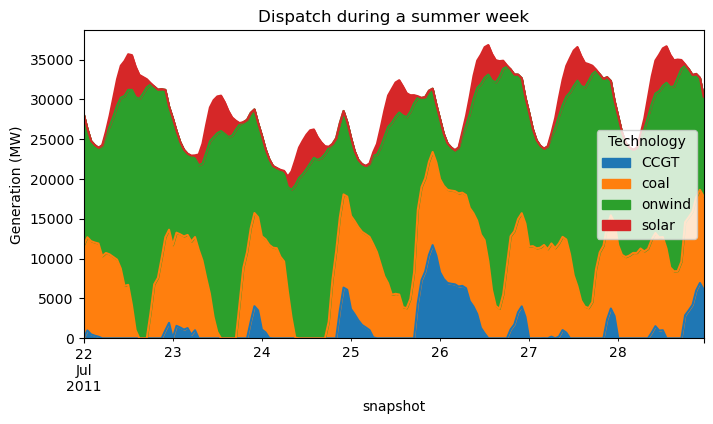

In [23]:
# dispatch time series for a week in summer
summer = dispatch_nostorage.loc["2011-07-22 00:00":"2011-07-28 23:00"]

summer.plot.area(figsize=(8,4))

plt.ylabel("Generation (MW)")
plt.title("Dispatch during a summer week")
plt.legend(title="Technology")
plt.show()

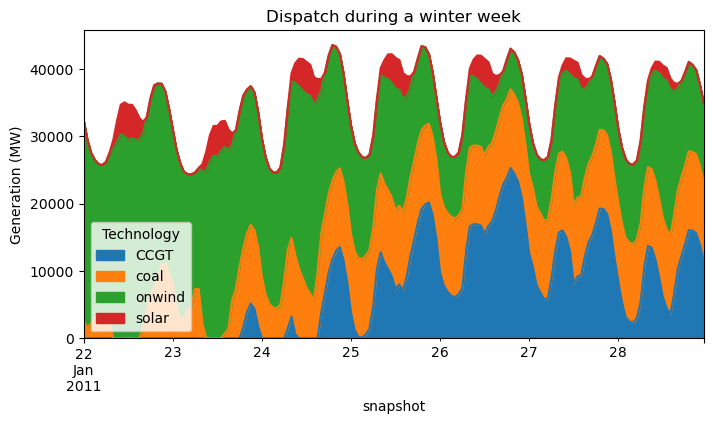

In [24]:
# dispatch time series for a week in winter
winter = dispatch_nostorage.loc["2011-01-22 00:00":"2011-01-28 23:00"]

winter.plot.area(figsize=(8,4))
plt.ylabel("Generation (MW)")
plt.title("Dispatch during a winter week")
plt.legend(title="Technology")
plt.show()

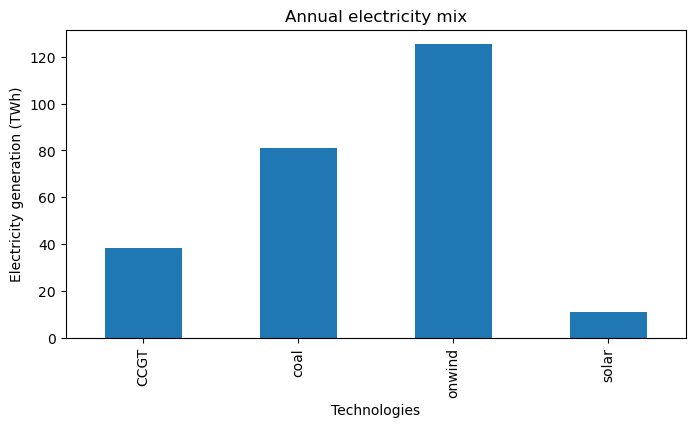

In [25]:
# Plot the annual electricity mix
annual_generation_nostorage = (dispatch_nostorage.sum()) / 1e6
annual_generation_nostorage.plot(kind="bar", figsize=(8,4))
plt.ylabel("Electricity generation (TWh)")
plt.xlabel("Technologies")
plt.title("Annual electricity mix")
plt.show()

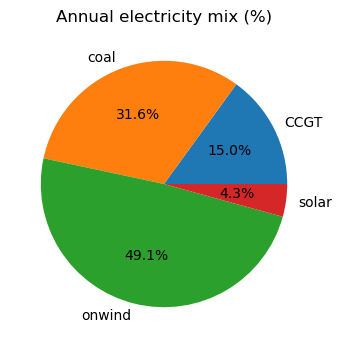

In [26]:
# Plot the annual electricity mix in %
mix_percent = 100 * annual_generation_nostorage / annual_generation_nostorage.sum()
mix_percent.plot(kind="pie", autopct="%1.1f%%", figsize=(8,4))
plt.ylabel("")
plt.title("Annual electricity mix (%)")
plt.show()

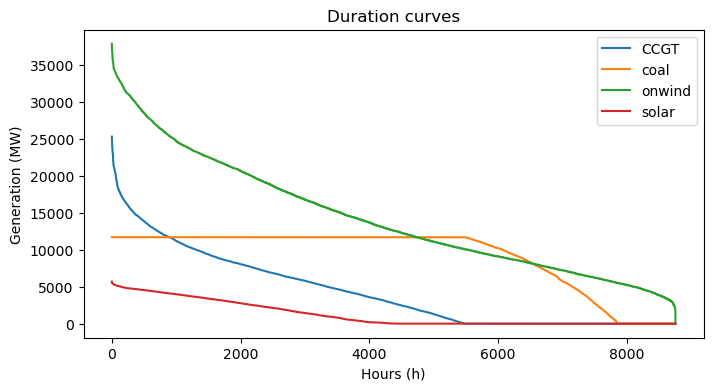

In [27]:
# Plot the duration curves 
# Describe the generation of each technology sorted from highest to lowest output over the year

plt.figure(figsize=(8,4))

for tech in dispatch_nostorage.columns:
    dispatch_nostorage[tech].sort_values(ascending=False).reset_index(drop=True).plot(label=tech)

plt.xlabel("Hours (h)")
plt.ylabel("Generation (MW)")
plt.title("Duration curves")
plt.legend()
plt.show()

## Question B 

- Investigate how sensitive your results are to the interannual variability of solar and wind generation.
Plot the average capacity and variability obtained for every generator using different weather years.

## Question C

- Add some storage technology/ies and investigate how they behave and what their impact is on the optimal system configuration. Discuss what strategies your system is using to balance the renewable generation at different time scales (intraday, seasonal, etc.)

## Joint capacity and dispatch optimization

In [28]:
# create an empty PyPSA network where later we will place buses, generators, loads, storage, lines
# we need a list with all hours in a year because electricty system are balanced every hour
n = pypsa.Network()

# creates a list of all hours, length = 8760 (number of hours in a year)
hours = pd.date_range('2011-01-01 00:00Z', '2011-12-31 23:00Z', freq='h')

n.set_snapshots(hours.values) 

# a bus is a connection point where electricity is balanced (meeting point in the model)
# generators inject electricity into the bus, loads take electricity from the bus (generation=demand)
n.add("Bus", #one bus = single-region model
            "Spain electricity") # one node called Spain electricity

n.snapshots

DatetimeIndex(['2011-01-01 00:00:00', '2011-01-01 01:00:00',
               '2011-01-01 02:00:00', '2011-01-01 03:00:00',
               '2011-01-01 04:00:00', '2011-01-01 05:00:00',
               '2011-01-01 06:00:00', '2011-01-01 07:00:00',
               '2011-01-01 08:00:00', '2011-01-01 09:00:00',
               ...
               '2011-12-31 14:00:00', '2011-12-31 15:00:00',
               '2011-12-31 16:00:00', '2011-12-31 17:00:00',
               '2011-12-31 18:00:00', '2011-12-31 19:00:00',
               '2011-12-31 20:00:00', '2011-12-31 21:00:00',
               '2011-12-31 22:00:00', '2011-12-31 23:00:00'],
              dtype='datetime64[ns]', name='snapshot', length=8760, freq=None)

In [29]:
# a carrier is a label for the type of technologies, it defines the categories
carriers = [
    "onwind",
    "solar",
    "coal",
    "CCGT",
    "PHS", #adding the storage technology -- pumped hydro storage
]

n.add(
    "Carrier",
    carriers,
    color=["dodgerblue", "gold", "indianred","yellow-green", "brown"], # colors that represent each carrier
)

In [30]:
# add load to the bus
# load mean electricity consumption (demand), in this case is Spain's electricity demand every hour of 2011
n.add("Load",
      "demand", #label, we can call what we want
      bus="Spain electricity",
      p_set=data_el[country].values) #p_set, fixed power consumption, the model cannot change this demand

#demand is fixed because demand is inelastic (demand does not respond to price)

In [31]:
# adding the generators, which generators exist and characteristics
# CCGT (gas turbine)
n.add(
    "Generator",
    "CCGT",
    bus="Spain electricity", #generators put electricity into the bus
    carrier="CCGT",
    # capital cost, marginal cost and efficiency are taken from the prerequisites
    capital_cost=costs.at["CCGT", "capital_cost"],
    marginal_cost=costs.at["CCGT", "marginal_cost"],
    efficiency=costs.at["CCGT", "efficiency"],
    p_nom_extendable=True,
    p_nom_max=25300, # 25.3 GW
)

# coal
n.add(
    "Generator",
    "coal",
    bus="Spain electricity", #generators put electricity into the bus
    carrier="coal",
    # capital cost, marginal cost and efficiency are taken from the prerequisites
    capital_cost=costs.at["coal", "capital_cost"],
    marginal_cost=costs.at["coal", "marginal_cost"],
    efficiency=costs.at["coal", "efficiency"],
    p_nom_extendable=True,
    p_nom_max=11700, # 11.7 GW
)

#capacity factor time series that are called in p_max_pu
CF_wind = data_wind[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in n.snapshots]]
# Onshore wind
n.add(
        "Generator",
        "onwind",
        bus="Spain electricity",
        carrier="onwind",
        p_max_pu=CF_wind.values, # since renewables cannot produce whenever they want, their output is limited by weather data
        capital_cost=costs.at["onwind", "capital_cost"],
        marginal_cost=costs.at["onwind", "marginal_cost"],
        efficiency=costs.at["onwind", "efficiency"],
        p_nom_extendable=True,
    )

#solar capacity factor
CF_solar = data_solar[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in n.snapshots]]
# Solar PV
n.add(
        "Generator",
        "solar",
        bus="Spain electricity",
        carrier="solar",
        p_max_pu= CF_solar.values,
        capital_cost=costs.at["solar", "capital_cost"],
        marginal_cost=costs.at["solar", "marginal_cost"],
        efficiency=costs.at["solar", "efficiency"],
        p_nom_extendable=True,
    )

# Pumped Hydro Storage
n.add(
    "StorageUnit",
    "PHS",
    bus="Spain electricity",
    carrier="PHS",
    max_hours=6,  # storage can discharge at full power for 6 hours
    capital_cost=costs.at["PHS", "capital_cost"],
    marginal_cost=costs.at["PHS", "marginal_cost"],
    # round-trip efficiency = charging efficiency * discharging efficiency
    efficiency_store=costs.at["PHS", "efficiency"]**0.5, # charging efficiency
    efficiency_dispatch=costs.at["PHS", "efficiency"]**0.5, # discharging efficiency
    p_nom_extendable=True,
    cyclic_state_of_charge=True,
)


# CCGT and coal do not have p_max_pu because is dispatchable, which means it can run whenever needed, as long it does not exceed the installed capacity

In [32]:
for df in [n.buses, n.loads, n.generators, n.carriers, n.storage_units]:
    for col in df.columns:
        if "ArrowStringArray" in str(type(df[col].array)):
            df[col] = df[col].astype("object")

n.buses.index = pd.Index(n.buses.index.tolist(), dtype=object)
n.loads.index = pd.Index(n.loads.index.tolist(), dtype=object)
n.generators.index = pd.Index(n.generators.index.tolist(), dtype=object)
n.carriers.index = pd.Index(n.carriers.index.tolist(), dtype=object)
n.storage_units.index = pd.Index(n.storage_units.index.tolist(), dtype=object)

n.buses.index.name = "name"
n.loads.index.name = "name"
n.generators.index.name = "name"
n.carriers.index.name = "name"
n.storage_units.index.name = "name"

## Model PyPSA

In [33]:
n.optimize(solver_name="highs")
# PyPS decides two things at the same time: capacity (how much technology to build) and dispatch (how much each generator produces in every hour of the year)

C:\Users\User\AppData\Local\Temp\ipykernel_35000\252832996.py:1: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize(solver_name="highs")
Index(['Spain electricity'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 241.49it/s]
INFO:linopy.io: Writing time: 0.22s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 61325 primals, 140167 duals
Objective: 1.70e+10
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit

('ok', 'optimal')

In [34]:
# how much capacity the model decided to build (optimised capacities in GW)
opt_caps = n.generators.p_nom_opt.div(1e3).round(2)

opt_caps_df = opt_caps.rename("Capacity (GW)").to_frame()

print(opt_caps_df)

        Capacity (GW)
name                 
CCGT            25.30
coal             7.09
onwind           4.34
solar           59.78


In [35]:
dispatch = n.generators_t.p

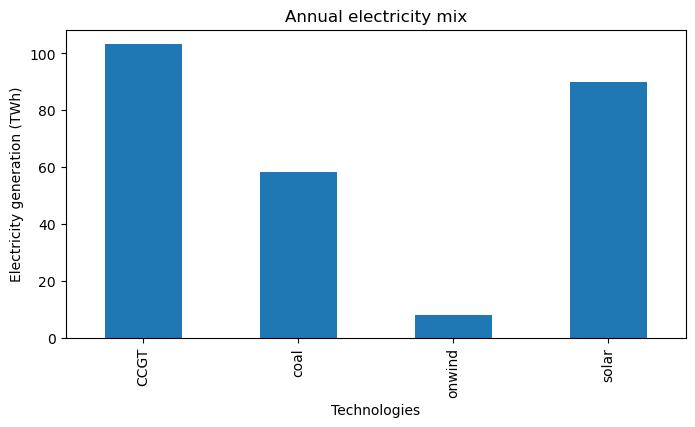

In [36]:
# Plot the annual electricity mix
annual_generation = (dispatch.sum())/ 1e6
annual_generation.plot(kind="bar", figsize=(8,4))
plt.ylabel("Electricity generation (TWh)")
plt.xlabel("Technologies")
plt.title("Annual electricity mix")
plt.show()

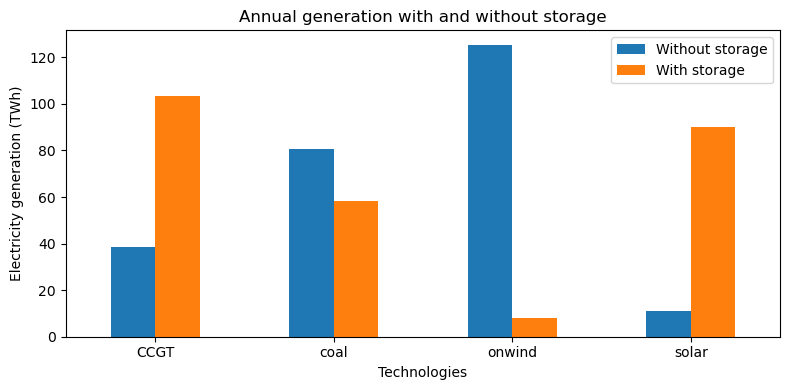

In [37]:
# --- Combine into one DataFrame ---
df_compare = pd.DataFrame({
    "Without storage": annual_generation_nostorage,
    "With storage": annual_generation
})

# Optional: sort technologies for nicer plot
df_compare = df_compare.sort_index()

# --- Plot ---
ax = df_compare.plot(kind="bar", figsize=(8,4))

plt.ylabel("Electricity generation (TWh)")
plt.xlabel("Technologies")
plt.title("Annual generation with and without storage")
plt.xticks(rotation=0)

plt.legend()
plt.tight_layout()
plt.show()

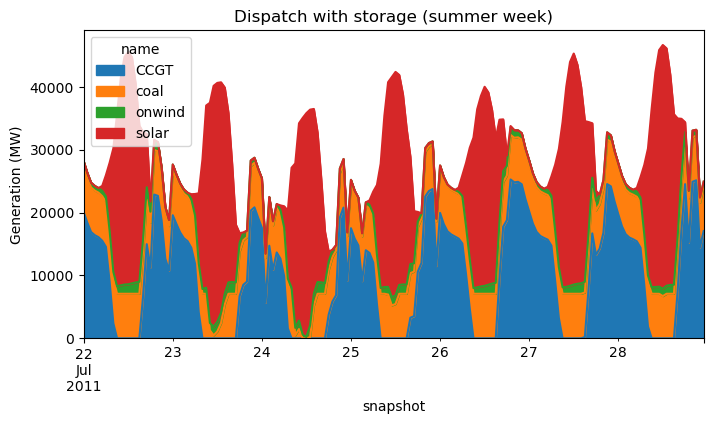

In [38]:
dispatch = n.generators_t.p

summer = dispatch.loc["2011-07-22":"2011-07-28"]

summer.plot.area(figsize=(8,4))
plt.ylabel("Generation (MW)")
plt.title("Dispatch with storage (summer week)")
plt.show()

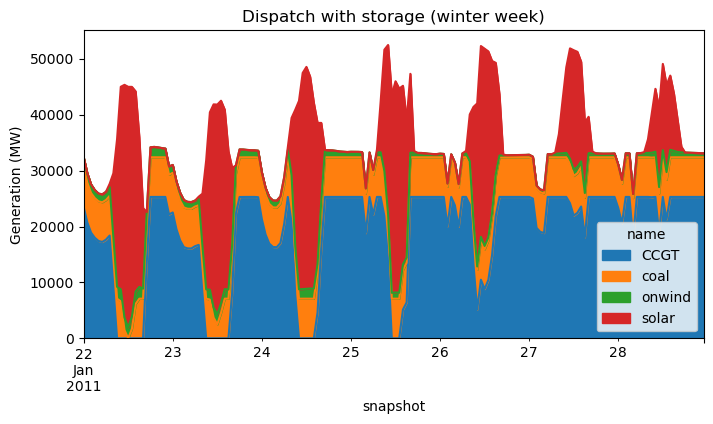

In [39]:
dispatch = n.generators_t.p

summer = dispatch.loc["2011-01-22":"2011-01-28"]

summer.plot.area(figsize=(8,4))
plt.ylabel("Generation (MW)")
plt.title("Dispatch with storage (winter week)")
plt.show()

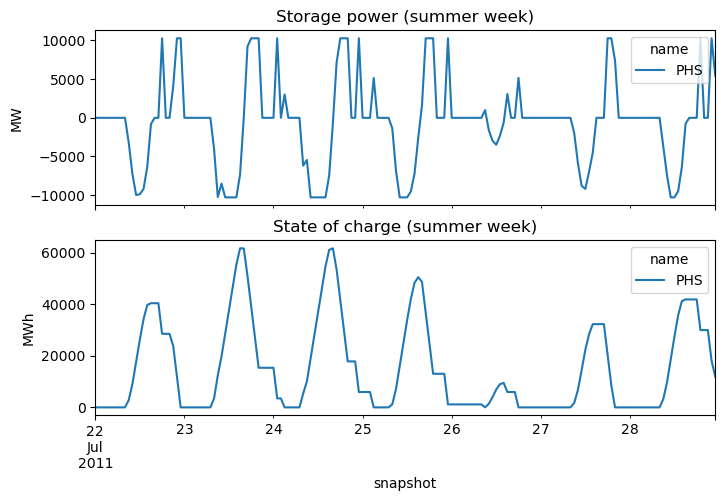

In [40]:
soc = n.storage_units_t.state_of_charge

summer_soc = soc.loc["2011-07-22":"2011-07-28"]
summer_p = n.storage_units_t.p.loc["2011-07-22":"2011-07-28"]

fig, ax = plt.subplots(2,1, figsize=(8,5), sharex=True)

summer_p.plot(ax=ax[0])
ax[0].set_title("Storage power (summer week)")
ax[0].set_ylabel("MW")

summer_soc.plot(ax=ax[1])
ax[1].set_title("State of charge (summer week)")
ax[1].set_ylabel("MWh")

plt.show()

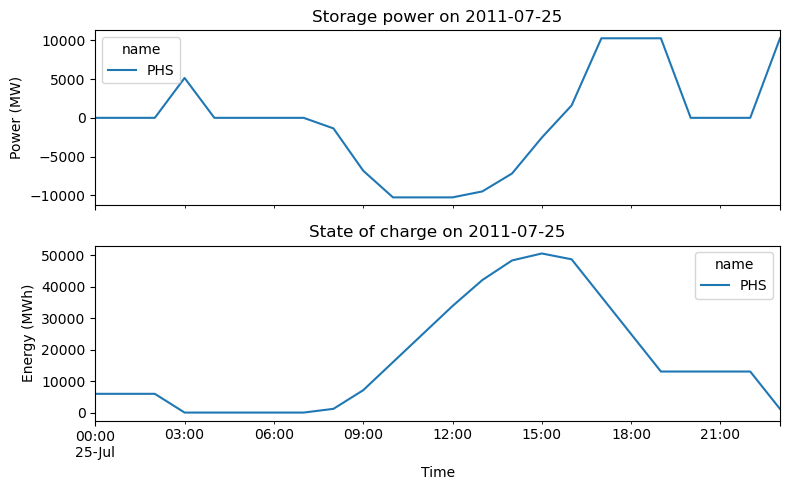

In [41]:
day = "2011-07-25"

storage_power_day = n.storage_units_t.p.loc[day]
soc_day = n.storage_units_t.state_of_charge.loc[day]

fig, ax = plt.subplots(2, 1, figsize=(8,5), sharex=True)

storage_power_day.plot(ax=ax[0])
ax[0].set_title(f"Storage power on {day}")
ax[0].set_ylabel("Power (MW)")

soc_day.plot(ax=ax[1])
ax[1].set_title(f"State of charge on {day}")
ax[1].set_ylabel("Energy (MWh)")
ax[1].set_xlabel("Time")

plt.tight_layout()
plt.show()

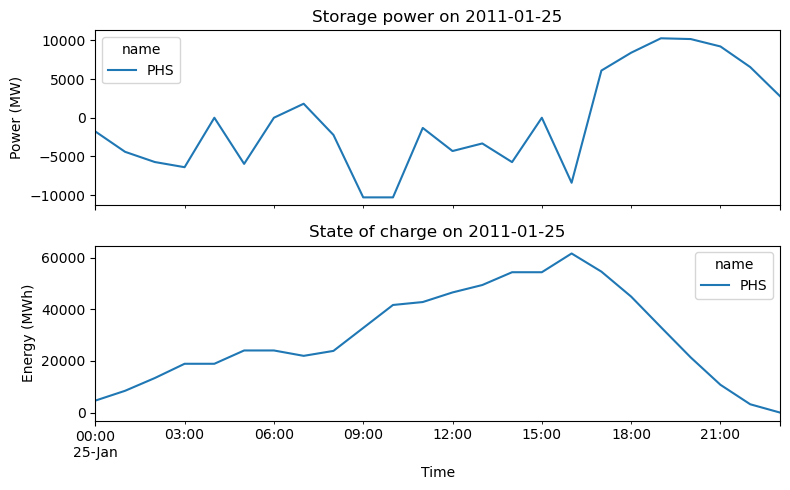

In [42]:
day = "2011-01-25"

storage_power_day = n.storage_units_t.p.loc[day]
soc_day = n.storage_units_t.state_of_charge.loc[day]

fig, ax = plt.subplots(2, 1, figsize=(8,5), sharex=True)

storage_power_day.plot(ax=ax[0])
ax[0].set_title(f"Storage power on {day}")
ax[0].set_ylabel("Power (MW)")

soc_day.plot(ax=ax[1])
ax[1].set_title(f"State of charge on {day}")
ax[1].set_ylabel("Energy (MWh)")
ax[1].set_xlabel("Time")

plt.tight_layout()
plt.show()

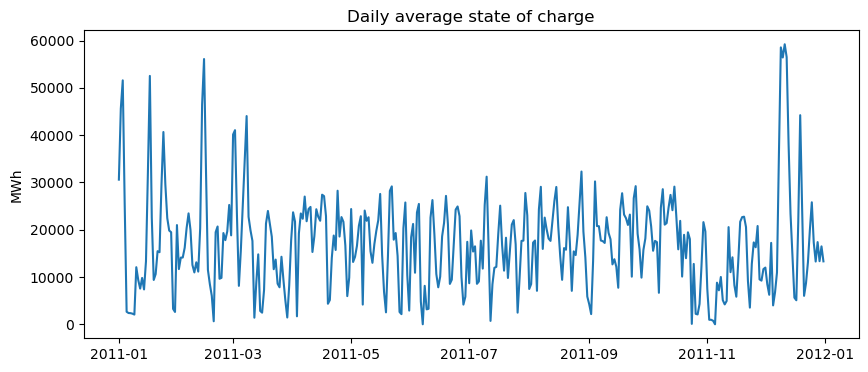

In [43]:
soc_daily = n.storage_units_t.state_of_charge.resample("D").mean()

plt.figure(figsize=(10,4))
plt.plot(soc_daily)
plt.title("Daily average state of charge")
plt.ylabel("MWh")
plt.show()

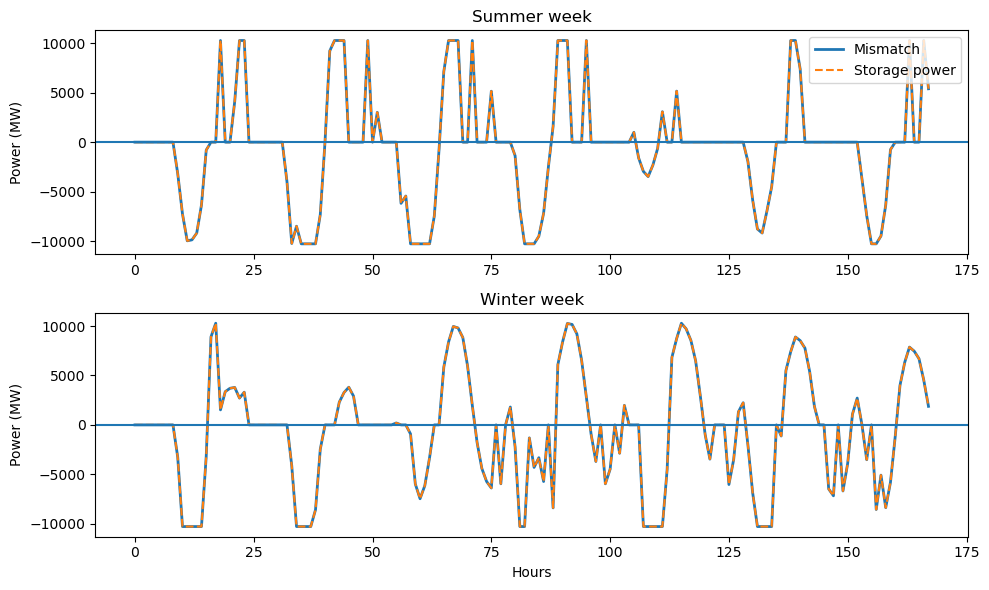

In [44]:
fig, ax = plt.subplots(2, 1, figsize=(10,6), sharex=False)

mismatch = n.loads_t.p_set["demand"] - n.generators_t.p.sum(axis=1)
# --- SUMMER ---
summer_mismatch = mismatch.loc["2011-07-22":"2011-07-28"]
summer_storage = n.storage_units_t.p.loc["2011-07-22":"2011-07-28"]

ax[0].plot(summer_mismatch.values, label="Mismatch", linewidth=2)
ax[0].plot(summer_storage.values, label="Storage power", linestyle="--")
ax[0].axhline(0)
ax[0].set_title("Summer week")
ax[0].set_ylabel("Power (MW)")
ax[0].legend()

# --- WINTER ---
winter_mismatch = mismatch.loc["2011-01-22":"2011-01-28"]
winter_storage = n.storage_units_t.p.loc["2011-01-22":"2011-01-28"]

ax[1].plot(winter_mismatch.values, label="Mismatch", linewidth=2)
ax[1].plot(winter_storage.values, label="Storage power", linestyle="--")
ax[1].axhline(0)
ax[1].set_title("Winter week")
ax[1].set_ylabel("Power (MW)")
ax[1].set_xlabel("Hours")

plt.tight_layout()
plt.show()

## Question D

- Connect your country to at least three neighbouring countries using HVAC lines, making sure that the network includes at least one closed cycle. Look for information on the existing capacities of those interconnectors and set the capacities fixed. Assume a voltage level of 400 kV and a unitary reactance x=0.1. You can assume that the generation capacities in the neighbouring countries are fixed or co-optimise the whole system. Optimise the whole system, assuming linearised AC power flow (DC approximation) and discuss the results.

In [45]:

# PART D - Multi-country network with DC power flow
# We copy the part-c network (n) and extend it with neighbouring countries

n.model.solver_model = None  # detach solver so we can copy
n_d = n.copy()

# Add neighbouring country buses
n_d.add("Bus", "FR", x=2.2137,  y=46.2276)
n_d.add("Bus", "PT", x=-8.2245, y=39.3999)
n_d.add("Bus", "MA", x=-7.0926, y=31.7917)

print('Existing buses:', n_d.buses.index.tolist())

Existing buses: ['Spain electricity', 'FR', 'PT', 'MA']


In [46]:
lines = [
    # (name,   bus0,              bus1,  s_nom MW, x p.u.)
    ("ES-FR",  "Spain electricity", "FR",  1300, 0.1),  # NTC France->Spain
    ("ES-PT",  "Spain electricity", "PT",  1700, 0.1),  # NTC Portugal->Spain
    ("FR-PT",  "FR",               "PT",  1500, 0.1),  # assumed virtual line
    ("ES-MA",  "Spain electricity", "MA",   900, 0.1),  # subsea cable
]

In [47]:
# 2. Add flat loads for neighbouring countries 
# Annual demand scaled to average MW: France ~480 TWh/yr, Portugal ~50 TWh/yr, Morocco ~35 TWh/yr
# Source: ENTSO-E statistical factsheets / IEA country data
demand_avg_mw = {
    "FR": 468e6 / 8760,   # ~53,425 MW — France 2011 ~468 TWh (Enerdata)
    "PT": 48e6  / 8760,   # ~5,479 MW  — Portugal 2011 ~48 TWh (REN)
    "MA": 28e6  / 8760,   # ~3,196 MW  — Morocco 2011 ~28 TWh (IEA)
}

for country_code, p_set in demand_avg_mw.items():
    n_d.add("Load", f"load_{country_code}", bus=country_code, p_set=p_set)

In [48]:
# 3. Add fixed-capacity generators for neighbouring countries 
# p_nom_extendable=False means these capacities are fixed, not optimised.
# p_max_pu=1.0 means fully dispatchable (can run at full capacity anytime)
#
# France: nuclear-dominated (63 GW nuclear), some wind
# Portugal: wind-heavy, some gas backup
# Morocco: gas + solar
# Sources: ENTSO-E, REN (Portugal), ONEE (Morocco)

neighbour_generators = {
    "FR": [
        ("nuclear_FR", "nuclear", 63000, 1.0, 5.0),
        ("wind_FR",    "onwind",  6600, 1.0, 1.4),
    ],
    "PT": [
        ("wind_PT", "onwind", 4378, 1.0, 1.4),
        ("gas_PT",  "CCGT",   3800, 1.0, 46.8),
    ],
    "MA": [
        ("thermal_MA",   "CCGT",  4771, 1.0, 46.8),
        ("wind_MA", "onwind", 292, 1.0, 1.4),
    ],
}

for country_code, gens in neighbour_generators.items():
    for name, carrier, p_nom, cf, mc in gens:
        n_d.add(
            "Generator", name,
            bus=country_code,
            carrier=carrier,
            p_nom=p_nom,
            p_nom_extendable=False,
            p_max_pu=cf,
            marginal_cost=mc,
        )

print('All generators:', n_d.generators.index.tolist())

All generators: ['CCGT', 'coal', 'onwind', 'solar', 'nuclear_FR', 'wind_FR', 'wind_PT', 'gas_PT', 'thermal_MA', 'wind_MA']


In [49]:
#  4. Add HVAC transmission lines (DC approximation) 
# Capacities are real NTC (Net Transfer Capacity) values from ENTSO-E.
# s_nom_extendable=False means line capacities are fixed as instructed.
# x=0.1 p.u. and v_nom=400 kV as specified in the assignment.
#
# The FR-PT line is crucial: it closes the triangular cycle ES -> FR -> PT -> ES
# A meshed/looped network is required for DC power flow (PTDF)
#
# NTC sources: ENTSO-E Ten-Year Network Development Plan (TYNDP)
lines = [
    # (name,   bus0,              bus1,  s_nom MW, x p.u.)
    ("ES-FR",  "Spain electricity", "FR",  2800, 0.1),
    ("ES-PT",  "Spain electricity", "PT",  3000, 0.1),
    ("FR-PT",  "FR",               "PT",  2200, 0.1),  # closes the cycle!
    ("ES-MA",  "Spain electricity", "MA",   900, 0.1),
]

for name, bus0, bus1, s_nom, x in lines:
    n_d.add(
        "Line", name,
        bus0=bus0,
        bus1=bus1,
        s_nom=s_nom,
        s_nom_extendable=False,
        x=x,
        v_nom=400,
    )

print('Lines added:', n_d.lines.index.tolist())

Lines added: ['ES-FR', 'ES-PT', 'FR-PT', 'ES-MA']


In [50]:
# 5. Fix ArrowStringArray dtype issue (same fix as in part c) 
for df in [n_d.buses, n_d.loads, n_d.generators, n_d.carriers, n_d.storage_units, n_d.lines]:
    for col in df.columns:
        if "ArrowStringArray" in str(type(df[col].array)):
            df[col] = df[col].astype("object")

n_d.buses.index = pd.Index(n_d.buses.index.tolist(), dtype=object)
n_d.lines.index = pd.Index(n_d.lines.index.tolist(), dtype=object)

In [51]:
# Fix index naming issue before optimising
for df in [n_d.buses, n_d.loads, n_d.generators, n_d.carriers, 
           n_d.storage_units, n_d.lines]:
    for col in df.columns:
        if "ArrowStringArray" in str(type(df[col].array)):
            df[col] = df[col].astype("object")

n_d.buses.index = pd.Index(n_d.buses.index.tolist(), dtype=object)
n_d.buses.index.name = "name"
n_d.lines.index = pd.Index(n_d.lines.index.tolist(), dtype=object)
n_d.lines.index.name = "name"
n_d.generators.index = pd.Index(n_d.generators.index.tolist(), dtype=object)
n_d.generators.index.name = "name"
n_d.loads.index = pd.Index(n_d.loads.index.tolist(), dtype=object)
n_d.loads.index.name = "name"

# Now optimise
n_d.optimize(solver_name="highs")

C:\Users\User\AppData\Local\Temp\ipykernel_35000\94441631.py:18: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n_d.optimize(solver_name="highs")


Index(['Spain electricity', 'FR', 'PT', 'MA'], dtype='object', name='name')
Index(['nuclear_FR'], dtype='object', name='name')
Index(['ES-FR', 'ES-PT', 'FR-PT', 'ES-MA'], dtype='object', name='name')
Index(['ES-FR', 'ES-PT', 'FR-PT', 'ES-MA'], dtype='object', name='name')
Index(['0'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 154.13it/s]
INFO:linopy.io: Writing time: 0.4s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 148925 primals, 350407 duals
Objective: 1.78e+10
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_sto

('ok', 'optimal')

In [52]:
# 6. Solve with linearised AC / DC approximation 
# PyPSA automatically uses DC power flow when Lines have reactance (x) defined.
# Spain's generators remain extendable (capacity co-optimised).
# Neighbour generators are fixed.

n_d.optimize(solver_name="highs")

C:\Users\User\AppData\Local\Temp\ipykernel_35000\1674718067.py:6: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n_d.optimize(solver_name="highs")
Index(['Spain electricity', 'FR', 'PT', 'MA'], dtype='object', name='name')


Index(['nuclear_FR'], dtype='object', name='name')
Index(['ES-FR', 'ES-PT', 'FR-PT', 'ES-MA'], dtype='object', name='name')
Index(['ES-FR', 'ES-PT', 'FR-PT', 'ES-MA'], dtype='object', name='name')
Index(['0'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 141.96it/s]
INFO:linopy.io: Writing time: 0.35s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 148925 primals, 350407 duals
Objective: 1.78e+10
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lo

('ok', 'optimal')

In [53]:
# 7. Results: optimal capacities in Spain 
spain_gens = n_d.generators[n_d.generators.bus == "Spain electricity"]
print("Optimal capacities in Spain (GW)")
print((n_d.generators.loc[spain_gens.index, "p_nom_opt"] / 1e3).round(2))

print("\nPHS storage capacity (GW)")
print((n_d.storage_units.p_nom_opt / 1e3).round(2))

Optimal capacities in Spain (GW)
name
CCGT      25.30
coal       0.64
onwind     4.34
solar     60.30
Name: p_nom_opt, dtype: float64

PHS storage capacity (GW)
name
PHS    10.28
Name: p_nom_opt, dtype: float64


In [54]:
# 8. Results: line flows
print("Average line flows (MW)")
print(n_d.lines_t.p0.mean().round(1))

print("\n Average line loading (% of capacity)")
line_loading_pct = (n_d.lines_t.p0.abs() / n_d.lines.s_nom * 100)
print(line_loading_pct.mean().round(1))

Average line flows (MW)
name
ES-FR   -2681.1
ES-PT    -798.5
FR-PT    1882.6
ES-MA    -569.6
dtype: float64

 Average line loading (% of capacity)
name
ES-FR    97.8
ES-PT    28.4
FR-PT    86.2
ES-MA    99.1
dtype: float64


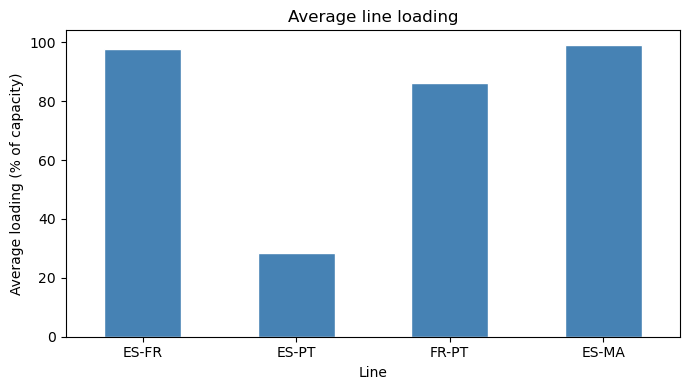

In [55]:
# 9. Plot: average line loading as % of capacity
fig, ax = plt.subplots(figsize=(7, 4))
line_loading_pct = (n_d.lines_t.p0.abs() / n_d.lines.s_nom * 100)
line_loading_pct.mean().plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_ylabel("Average loading (% of capacity)")
ax.set_title("Average line loading")
ax.set_xlabel("Line")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

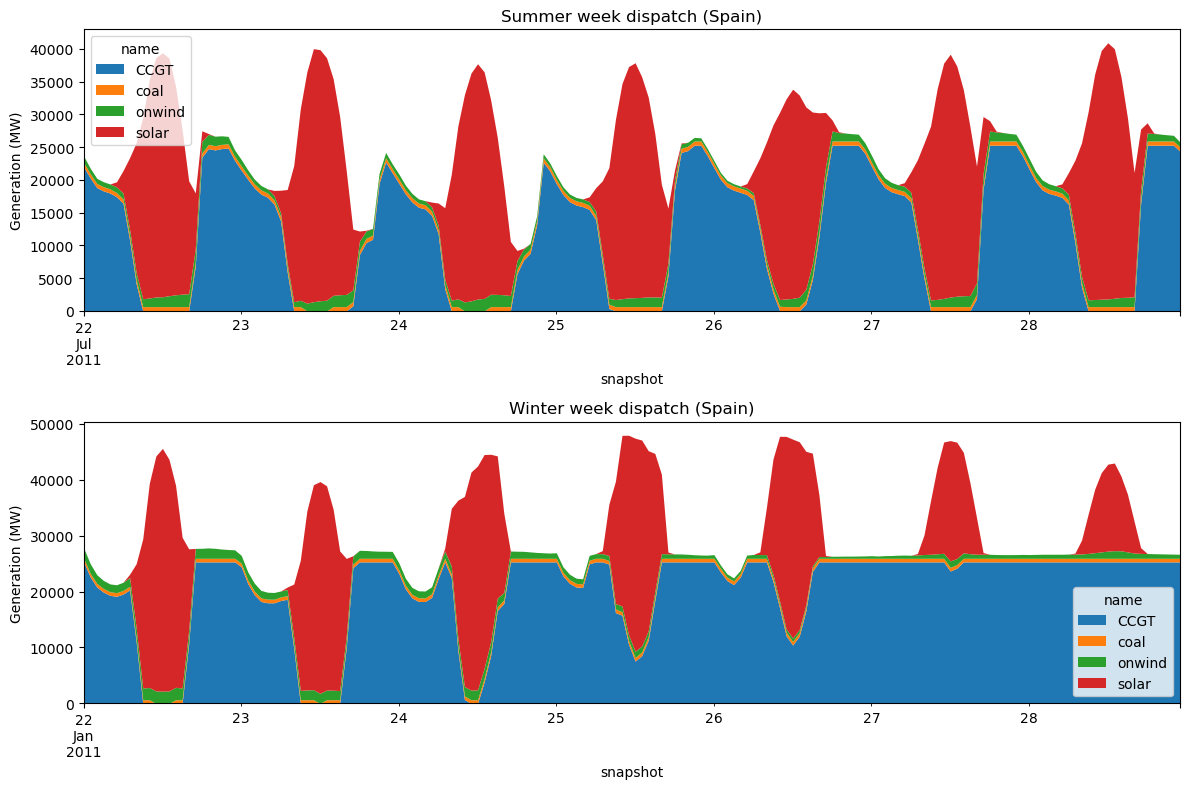

In [56]:
# 10. Plot: Spain dispatch for summer and winter week
spain_gen_cols = n_d.generators[n_d.generators.bus =="Spain electricity"].index

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

for ax, start, title in zip(
    axes,
    ["2011-07-22", "2011-01-22"],
    ["Summer week dispatch (Spain)", "Winter week dispatch (Spain)"],
):
    week = n_d.generators_t.p.loc[start:].iloc[:168][spain_gen_cols]
    week.plot.area(ax=ax, title=title, linewidth=0)
    ax.set_ylabel("Generation (MW)")
    ax.set_xlabel("snapshot")

plt.tight_layout()
plt.show()

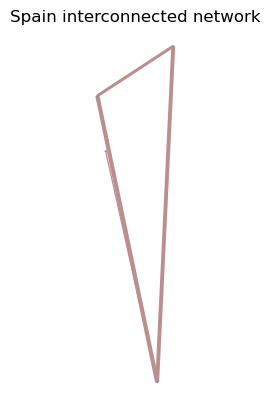

In [57]:
# 11. plot the network on a map
# Requires cartopy or geopandas.
try:
    n_d.plot(title="Spain interconnected network", line_widths=n_d.lines.s_nom / 1000)
    plt.show()
except Exception as e:
    print(f'Map plot skipped: {e}')
    print('Install cartopy for geographic map plotting.')

In [58]:
# Incidence matrix from PyPSA
sub_network = n_d.sub_networks.obj["0"]
sub_network.calculate_PTDF()

incidence_matrix = sub_network.K  # incidence matrix
PTDF_matrix = sub_network.PTDF   # PTDF matrix

print("Incidence matrix:\n", incidence_matrix)
print("\nPTDF matrix:\n", PTDF_matrix)

Incidence matrix:
 <Compressed Sparse Row sparse matrix of dtype 'float64'
	with 8 stored elements and shape (4, 4)>
  Coords	Values
  (0, 0)	1.0
  (0, 1)	1.0
  (0, 3)	1.0
  (1, 0)	-1.0
  (1, 2)	1.0
  (2, 1)	-1.0
  (2, 2)	-1.0
  (3, 3)	-1.0

PTDF matrix:
 [[ 0.         -0.66666667 -0.33333333  0.        ]
 [ 0.         -0.33333333 -0.66666667  0.        ]
 [ 0.          0.33333333 -0.33333333  0.        ]
 [ 0.          0.          0.         -1.        ]]


In [59]:
# Generation at each bus, first timestep
t0 = n_d.snapshots[0]

gen_per_bus = n_d.generators_t.p.loc[t0].groupby(n_d.generators.bus).sum()
load_per_bus = n_d.loads_t.p.loc[t0].groupby(n_d.loads.bus).sum()

imbalance = gen_per_bus.subtract(load_per_bus, fill_value=0)
print("Nodal imbalances at t=0 (MW):\n", imbalance)

Nodal imbalances at t=0 (MW):
 bus
FR                   4750.726027
MA                    900.000000
PT                  -1101.452055
Spain electricity   -4549.273973
Name: 2011-01-01 00:00:00, dtype: float64
